# OPTICS：多密度结构、可达距离图与多尺度簇提取

本实验用三个密度水平明显不同的二维簇和人工噪声，展示一套完整的 OPTICS 分析流程：

1. 标准化数据并诊断局部密度差异；
2. 拟合 OPTICS；
3. 用 reachability plot 识别谷地，并以 $\xi$ 方法提取簇；
4. 检查 `MinPts`、$\xi$ 和最小簇规模的敏感性；
5. 汇总簇规模、噪声比例、内部指标和外部验证指标。

In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
import numpy as np
import pandas as pd
from sklearn.cluster import OPTICS
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SINGLE_FIGSIZE = (8, 5.5)
COLORS = ["#4C78A8", "#F28E2B", "#59A14F", "#B279A2", "#76B7B2"]
RANDOM_STATE = 42

## 1. 构造不同密度的簇

三个簇的样本量和标准差分别不同。最左侧簇最紧密，中间簇密度居中，右侧簇最稀疏；此外加入均匀噪声。

,samples,generating std
dense cluster,160,0.25
medium cluster,220,0.60
sparse cluster,280,1.10
injected noise,45,NaN


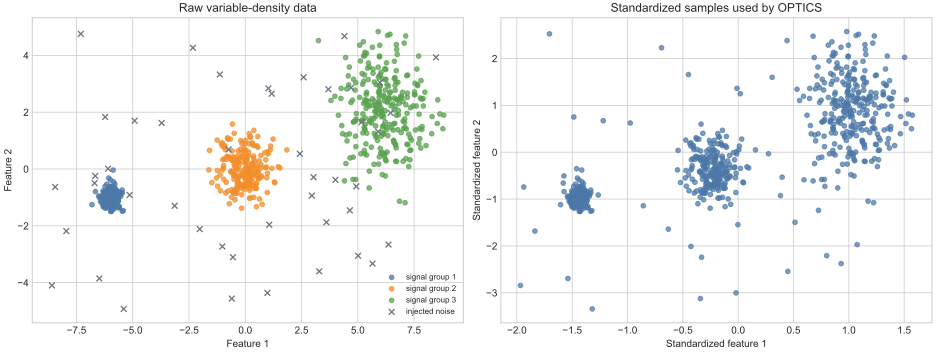

In [2]:
X_signal, y_signal = make_blobs(
    n_samples=[160, 220, 280],
    centers=[(-6, -1), (0, 0), (6, 2)],
    cluster_std=[0.25, 0.60, 1.10],
    random_state=RANDOM_STATE,
)
rng = np.random.default_rng(RANDOM_STATE)
X_noise = rng.uniform(low=[-9, -5], high=[9, 5], size=(45, 2))
X = np.vstack([X_signal, X_noise])
y_true = np.concatenate([y_signal, np.full(len(X_noise), -1)])
X_scaled = StandardScaler().fit_transform(X)

data_summary = pd.DataFrame(
    {
        "samples": [160, 220, 280, 45],
        "generating std": [0.25, 0.60, 1.10, np.nan],
    },
    index=["dense cluster", "medium cluster", "sparse cluster", "injected noise"],
)
display(data_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.9), constrained_layout=True)
for cluster_id in range(3):
    mask = y_signal == cluster_id
    axes[0].scatter(X_signal[mask, 0], X_signal[mask, 1], s=22, alpha=0.75, color=COLORS[cluster_id], label=f"signal group {cluster_id + 1}")
axes[0].scatter(X_noise[:, 0], X_noise[:, 1], s=34, marker="x", color="#6B7280", linewidth=1.3, label="injected noise")
axes[0].set(title="Raw variable-density data", xlabel="Feature 1", ylabel="Feature 2")
axes[0].legend(fontsize=8)
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], s=22, alpha=0.72, color="#4C78A8")
axes[1].set(title="Standardized samples used by OPTICS", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
plt.show()

## 2. 诊断局部密度差异

取 `MinPts = 10`，计算每个样本到第 10 个近邻的距离。距离越小表示达到相同邻居数量所需的半径越小，即局部密度越高。

,median 10-distance,90% 10-distance
dense cluster,0.040,0.078
medium cluster,0.083,0.176
sparse cluster,0.144,0.266
injected noise,0.624,1.484


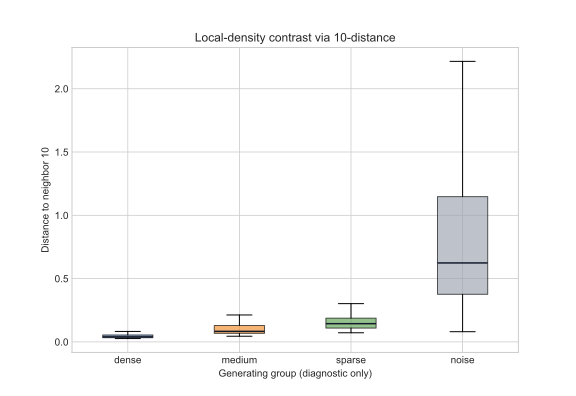

In [3]:
min_samples = 10
neighbor_model = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
neighbor_distances, _ = neighbor_model.kneighbors(X_scaled)
k_distance = neighbor_distances[:, -1]
density_diagnostic = pd.DataFrame(
    {
        "median 10-distance": [np.median(k_distance[y_true == label]) for label in [0, 1, 2, -1]],
        "90% 10-distance": [np.quantile(k_distance[y_true == label], 0.90) for label in [0, 1, 2, -1]],
    },
    index=["dense cluster", "medium cluster", "sparse cluster", "injected noise"],
)
display(density_diagnostic.round(3))

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
distance_groups = [k_distance[y_true == label] for label in [0, 1, 2, -1]]
boxes = ax.boxplot(distance_groups, patch_artist=True, showfliers=False, medianprops={"color": "#111827", "linewidth": 1.5})
for patch, color in zip(boxes["boxes"], COLORS[:3] + ["#9CA3AF"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.set_xticklabels(["dense", "medium", "sparse", "noise"])
ax.set(title="Local-density contrast via 10-distance", xlabel="Generating group (diagnostic only)", ylabel="Distance to neighbor 10")
plt.show()

## 3. 拟合 OPTICS 并读取可达距离图

采用 `MinPts = 10`、$\xi=0.07$ 和最小簇规模 $5\%$。`max_eps = np.inf` 表示不预先截断邻域尺度。OPTICS 先产生样本排序，再用 $\xi$ 方法识别 reachability plot 中相对陡峭的下降与上升边界。

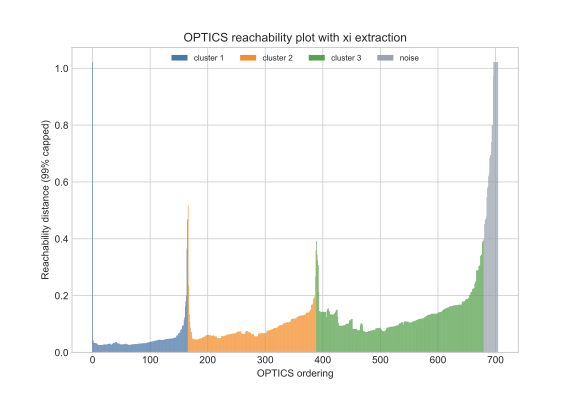

In [4]:
chosen_xi = 0.07
chosen_min_cluster_size = 0.05
optics = OPTICS(
    min_samples=min_samples,
    max_eps=np.inf,
    xi=chosen_xi,
    min_cluster_size=chosen_min_cluster_size,
    cluster_method="xi",
).fit(X_scaled)
labels = optics.labels_
ordering = optics.ordering_
ordered_reachability = optics.reachability_[ordering]
ordered_labels = labels[ordering]
finite_reachability = ordered_reachability[np.isfinite(ordered_reachability)]
reachability_cap = np.quantile(finite_reachability, 0.99)
plot_reachability = np.minimum(ordered_reachability, reachability_cap)
cluster_ids = sorted(set(labels) - {-1})

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
positions = np.arange(len(X_scaled))
for cluster_id in cluster_ids:
    mask = ordered_labels == cluster_id
    ax.bar(positions[mask], plot_reachability[mask], width=1.0, color=COLORS[cluster_id % len(COLORS)], label=f"cluster {cluster_id + 1}")
noise_ordered = ordered_labels == -1
ax.bar(positions[noise_ordered], plot_reachability[noise_ordered], width=1.0, color="#9CA3AF", label="noise")
ax.set(title="OPTICS reachability plot with xi extraction", xlabel="OPTICS ordering", ylabel="Reachability distance (99% capped)")
ax.legend(ncol=4, fontsize=8)
plt.show()

## 4. 检查参数敏感性

下面联合改变 `MinPts` 与 $\xi$，固定最小簇规模为 $5\%$。调参时主要查看簇数、噪声比例和非噪声样本的 Silhouette；ARI 依赖真实标签，只作为模拟实验的事后验证。$\xi$ 越小，算法越容易把较小的局部下降识别成独立簇，也更容易产生碎片化。

,MinPts,clusters,noise_rate,silhouette_non_noise,ARI_all
xi,,,,,
0.03,10,4,0.658,0.734,0.132
0.05,10,3,0.340,0.677,0.603
0.07,10,3,0.035,0.640,0.945
0.09,10,3,0.037,0.641,0.947


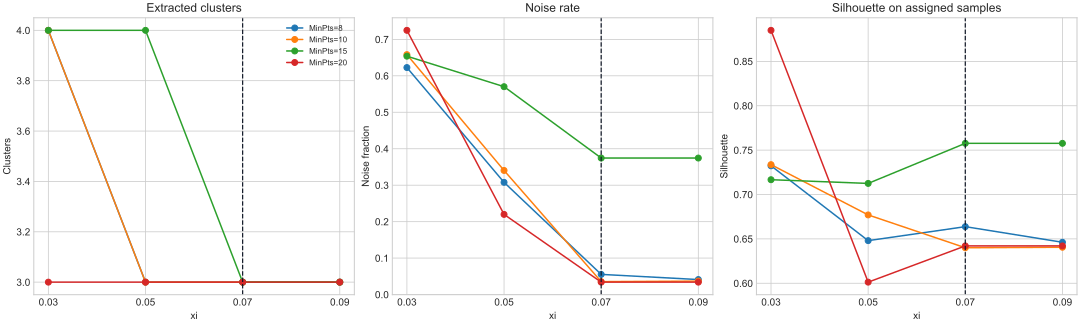

In [5]:
min_samples_values = [8, 10, 15, 20]
xi_values = [0.03, 0.05, 0.07, 0.09]
rows = []
for current_min_samples in min_samples_values:
    for current_xi in xi_values:
        current_labels = OPTICS(
            min_samples=current_min_samples,
            max_eps=np.inf,
            xi=current_xi,
            min_cluster_size=chosen_min_cluster_size,
            cluster_method="xi",
        ).fit_predict(X_scaled)
        current_non_noise = current_labels != -1
        current_clusters = len(set(current_labels) - {-1})
        current_silhouette = np.nan
        if current_clusters >= 2 and current_non_noise.sum() > current_clusters:
            current_silhouette = silhouette_score(X_scaled[current_non_noise], current_labels[current_non_noise])
        rows.append(
            {
                "MinPts": current_min_samples,
                "xi": current_xi,
                "clusters": current_clusters,
                "noise_rate": (~current_non_noise).mean(),
                "silhouette_non_noise": current_silhouette,
                "ARI_all": adjusted_rand_score(y_true, current_labels),
            }
        )
sensitivity = pd.DataFrame(rows)
display(sensitivity.query("MinPts == 10").set_index("xi").round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for current_min_samples in min_samples_values:
    part = sensitivity[sensitivity["MinPts"] == current_min_samples]
    axes[0].plot(part["xi"], part["clusters"], marker="o", label=f"MinPts={current_min_samples}")
    axes[1].plot(part["xi"], part["noise_rate"], marker="o")
    axes[2].plot(part["xi"], part["silhouette_non_noise"], marker="o")
axes[0].legend(fontsize=8)
for ax, title, ylabel in zip(axes, ["Extracted clusters", "Noise rate", "Silhouette on assigned samples"], ["Clusters", "Noise fraction", "Silhouette"]):
    ax.axvline(chosen_xi, color="#111827", linestyle="--", linewidth=1.2)
    ax.set(title=title, xlabel="xi", ylabel=ylabel, xticks=xi_values)
plt.show()

## 5. 最终聚类结果与评价

最终图同时给出 $\xi$ 提取的簇和噪声点。Silhouette 只在已分配样本上计算；整体 ARI 将真实噪声和预测噪声都视为标签的一部分；signal-only ARI 只在真实非噪声样本上计算，并仍会惩罚被错误标为噪声的主体样本。噪声 precision 与 recall 则单独评价异常点识别。

,samples
cluster 1,166
cluster 2,223
cluster 3,291


,value
clusters,3.000
noise samples,25.000
noise rate,0.035
silhouette (non-noise),0.640
ARI (all samples),0.945
ARI (true signal only),0.997
noise precision,0.960
noise recall,0.533


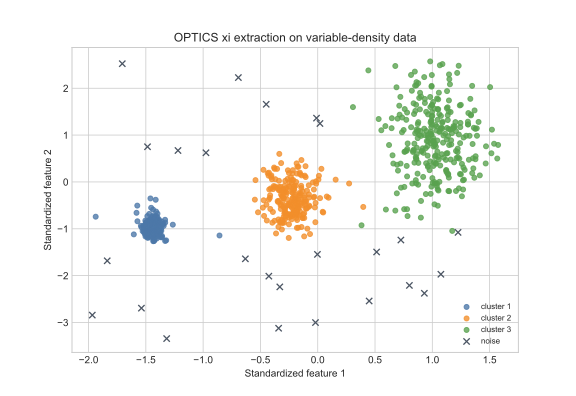

In [6]:
noise_mask = labels == -1
non_noise = ~noise_mask
true_noise = y_true == -1
signal_mask = ~true_noise
true_positive_noise = np.sum(noise_mask & true_noise)
cluster_summary = pd.Series(labels[non_noise]).value_counts().sort_index().rename_axis("cluster").to_frame("samples")
cluster_summary.index = [f"cluster {index + 1}" for index in cluster_summary.index]
display(cluster_summary)
evaluation = pd.Series(
    {
        "clusters": len(cluster_ids),
        "noise samples": int(noise_mask.sum()),
        "noise rate": noise_mask.mean(),
        "silhouette (non-noise)": silhouette_score(X_scaled[non_noise], labels[non_noise]),
        "ARI (all samples)": adjusted_rand_score(y_true, labels),
        "ARI (true signal only)": adjusted_rand_score(y_true[signal_mask], labels[signal_mask]),
        "noise precision": true_positive_noise / max(noise_mask.sum(), 1),
        "noise recall": true_positive_noise / true_noise.sum(),
    },
    name="value",
).to_frame()
display(evaluation.round(3))

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
for cluster_id in cluster_ids:
    mask = labels == cluster_id
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=25, alpha=0.78, color=COLORS[cluster_id % len(COLORS)], label=f"cluster {cluster_id + 1}")
ax.scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], s=40, marker="x", color="#4B5563", linewidth=1.3, label="noise")
ax.set(title="OPTICS xi extraction on variable-density data", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
ax.legend(fontsize=8)
plt.show()